In [1]:
!pip -q install pillow h5py

import os, io
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
H5_PATH = "../hydrofoil_webp.hdf5"
print(os.path.exists(H5_PATH), H5_PATH)


with h5py.File(H5_PATH, "r") as f:
    print("Keys:", list(f.keys()))
    for k in f.keys():
        try:
            print(k, f[k].shape, f[k].dtype)
        except:
            pass



True ./hydrofoil_webp.hdf5
Keys: ['colors_webp', 'hdri_rotation', 'hdri_source', 'ride_height', 'velocity']
colors_webp (3200,) object
hdri_rotation (3200,) float32
hdri_source (3200,) object
ride_height (3200,) float32
velocity (3200,) float32


In [3]:

class HydroWebpH5Dataset(Dataset):
    def __init__(self, h5_path, img_key="colors_webp", y_key="ride_height", transform=None):
        self.h5_path = h5_path
        self.img_key = img_key
        self.y_key = y_key
        self.transform = transform
        with h5py.File(self.h5_path, "r") as f:
            self.n = f[self.y_key].shape[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        with h5py.File(self.h5_path, "r") as f:
            webp_obj = f[self.img_key][idx]
            y = float(f[self.y_key][idx])

        # decode bytes -> RGB image
        webp_bytes = webp_obj if isinstance(webp_obj, (bytes, bytearray)) else bytes(webp_obj)
        img = Image.open(io.BytesIO(webp_bytes)).convert("RGB")
        img = np.array(img)  # HxWx3 uint8

        x = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0  # CHW float

        if self.transform:
            x = self.transform(x)

        y = torch.tensor([y], dtype=torch.float32)
        return x, y

In [ ]:
H5_PATH = "../hydrofoil_webp.hdf5"

transform = T.Compose([
    T.Resize((224, 224)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

ds = HydroWebpH5Dataset(H5_PATH, img_key="colors_webp", y_key="ride_height", transform=transform)

n = len(ds)
train_n = int(0.8 * n)
val_n = n - train_n
train_ds, val_ds = random_split(ds, [train_n, val_n])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

print("Total:", n, "Train:", train_n, "Val:", val_n)
print("Total:", n, "Train:", train_n, "Val:", val_n)

Total: 3200 Train: 2560 Val: 640
Total: 3200 Train: 2560 Val: 640


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 1)   # single scalar output (ride_height)
model = model.to(device)

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/andre/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 18.9MB/s]


In [11]:
from tqdm import tqdm

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

def evaluate():
    model.eval()
    losses = []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            losses.append(criterion(pred, y).item())
    return float(np.mean(losses))

EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    val_loss = evaluate()
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | train={np.mean(train_losses):.6f} | val={val_loss:.6f}")


Epoch 01/20 | train=0.005375 | val=0.000773


Epoch 02/20 | train=0.001129 | val=0.000548


Epoch 03/20 | train=0.000405 | val=0.000224


Epoch 04/20 | train=0.000338 | val=0.000507


Epoch 05/20 | train=0.000369 | val=0.000328


...

Epoch 16/20 | train=0.000134 | val=0.000199


Epoch 17/20 | train=0.000293 | val=0.000190


Epoch 18/20 | train=0.000198 | val=0.000104


Epoch 19/20 | train=0.000222 | val=0.000133


Epoch 20/20 | train=0.000123 | val=0.000146


MAE: 0.009572486
RMSE: 0.012100331


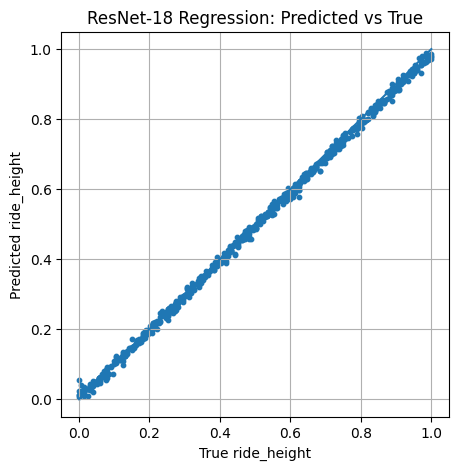

In [12]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        pred = model(x).cpu().numpy().flatten()
        y_true.extend(y.numpy().flatten())
        y_pred.extend(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

mae = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true)**2))
print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=10)
mn, mx = float(min(y_true.min(), y_pred.min())), float(max(y_true.max(), y_pred.max()))
plt.plot([mn, mx], [mn, mx])  # y=x reference
plt.xlabel("True ride_height")
plt.ylabel("Predicted ride_height")
plt.title("ResNet-18 Regression: Predicted vs True")
plt.grid(True)
plt.show()